Libraries Imported Successfully

PCA Features Loaded Successfully

Feature Shape:
(19947, 50)

Clustered Dataset Loaded Successfully

Dataset Shape:
(19947, 16)

Cluster Columns:
['kmeans_cluster', 'agg_cluster', 'dbscan_cluster']

Evaluating KMeans...

KMeans Evaluation Completed

Evaluating Agglomerative Clustering...

Agglomerative Evaluation Completed

Evaluating DBSCAN...

DBSCAN Evaluation Completed

Model Evaluation Results:


,Model,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Score
0,KMeans,0.722998,0.570194,28163.370450
1,Agglomerative,0.754363,0.502509,25936.237828
2,DBSCAN,0.886009,0.399186,1079.118242



Evaluation Results Saved Successfully


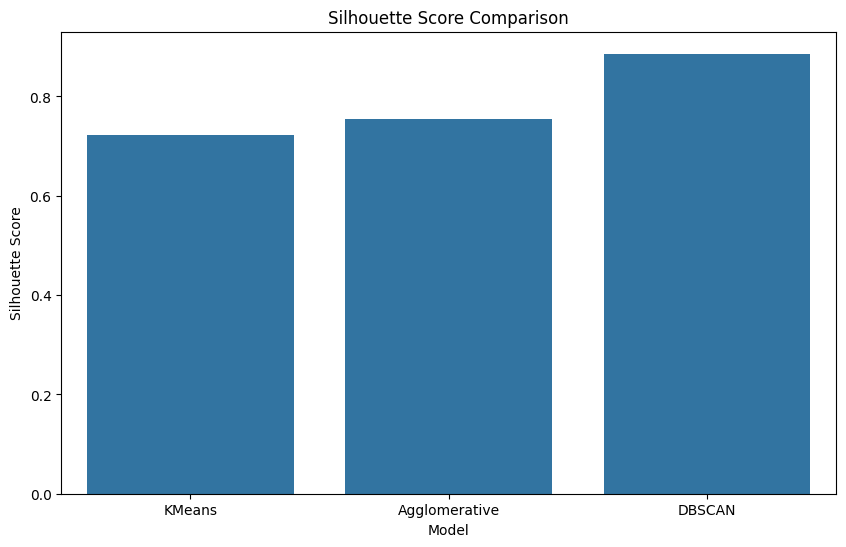

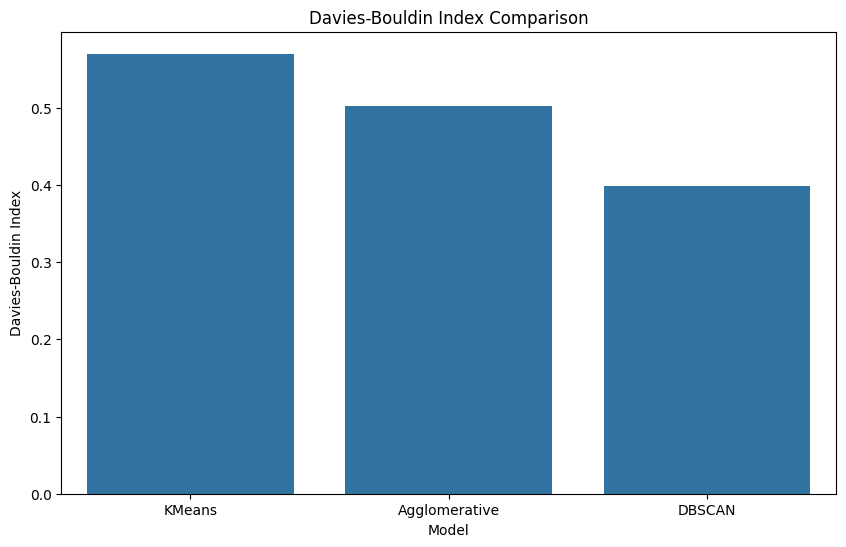

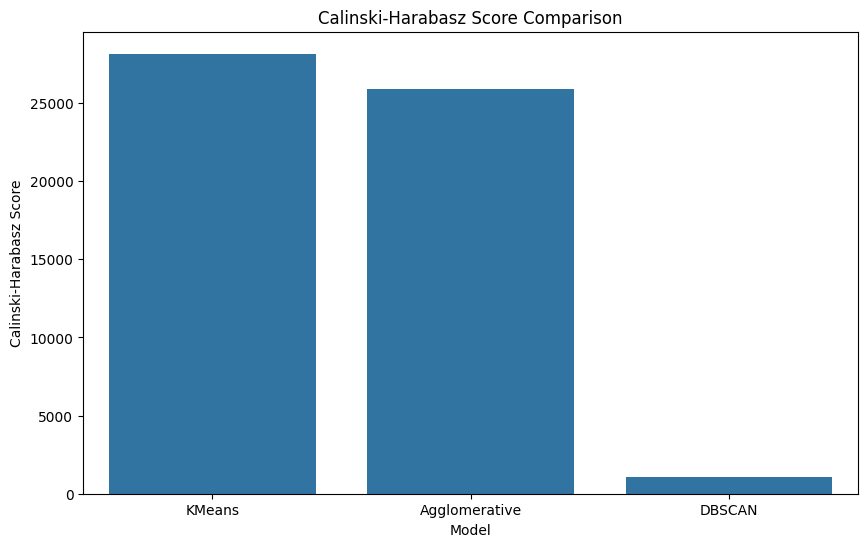


BEST CLUSTERING MODEL

Model: DBSCAN

Silhouette Score: 0.8860

Davies-Bouldin Index: 0.3992

Calinski-Harabasz Score: 1079.1182

KMeans Cluster Distribution:
kmeans_cluster
0    17849
1     2098
Name: count, dtype: int64

Agglomerative Cluster Distribution:
agg_cluster
0    18675
1     1272
Name: count, dtype: int64

DBSCAN Cluster Distribution:
dbscan_cluster
 0    19934
-1        8
 1        5
Name: count, dtype: int64


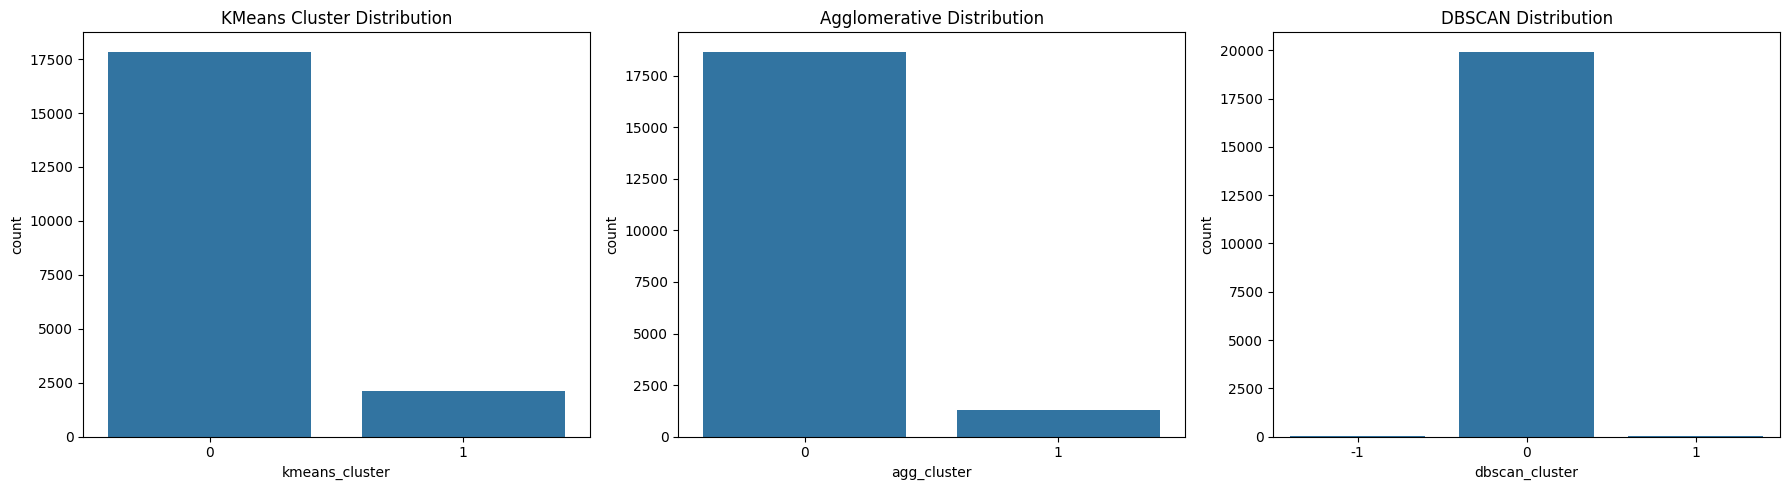


OVER-CLUSTERING ANALYSIS

Small Clusters (<50 samples): 0

UNDER-CLUSTERING ANALYSIS

Largest Cluster Percentage: 89.48%

METRIC INTERPRETATION

1. Silhouette Score
Higher is better
Range: -1 to 1

2. Davies-Bouldin Index
Lower is better

3. Calinski-Harabasz Score
Higher is better

BUSINESS INSIGHTS

Good clustering indicates:
- Similar reviews grouped together
- Hidden customer patterns identified
- Better review segmentation
- Improved recommendation understanding
- Potential fake review patterns

Evaluation Summary Saved Successfully

NOTEBOOK 05 COMPLETED SUCCESSFULLY

Tasks Completed:
1. KMeans Evaluation
2. Agglomerative Evaluation
3. DBSCAN Evaluation
4. Silhouette Score Analysis
5. Davies-Bouldin Analysis
6. Calinski-Harabasz Analysis
7. Model Comparison
8. Cluster Distribution Analysis
9. Over-Clustering Detection
10. Under-Clustering Detection
11. Business Interpretation
12. Evaluation Reports Saved

Ready for Notebook 06 — Business Insights


In [1]:
# ============================================================
# AMAZON BOOK REVIEWS CLUSTERING PROJECT
# NOTEBOOK: 05_model_evaluation.ipynb
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (

    silhouette_score,

    davies_bouldin_score,

    calinski_harabasz_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")


# ============================================================
# STEP 2 — LOAD PCA FEATURES
# ============================================================

PCA_PATH = (
    "../data/processed/"
    "pca_features.csv"
)

pca_df = pd.read_csv(PCA_PATH)

X = pca_df.values

print("\nPCA Features Loaded Successfully")

print("\nFeature Shape:")
print(X.shape)


# ============================================================
# STEP 3 — LOAD CLUSTERED DATASET
# ============================================================

CLUSTER_PATH = (
    "../data/processed/"
    "clustered_reviews.csv"
)

df = pd.read_csv(CLUSTER_PATH)

print("\nClustered Dataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# STEP 4 — CHECK CLUSTER COLUMNS
# ============================================================

cluster_columns = [

    "kmeans_cluster",

    "agg_cluster",

    "dbscan_cluster"
]

print("\nCluster Columns:")

print(cluster_columns)


# ============================================================
# STEP 5 — KMEANS EVALUATION
# ============================================================

kmeans_labels = df[
    "kmeans_cluster"
]

print("\nEvaluating KMeans...")

kmeans_silhouette = silhouette_score(

    X,

    kmeans_labels
)

kmeans_davies = davies_bouldin_score(

    X,

    kmeans_labels
)

kmeans_calinski = calinski_harabasz_score(

    X,

    kmeans_labels
)

print("\nKMeans Evaluation Completed")


# ============================================================
# STEP 6 — AGGLOMERATIVE EVALUATION
# ============================================================

agg_labels = df[
    "agg_cluster"
]

print("\nEvaluating Agglomerative Clustering...")

agg_silhouette = silhouette_score(

    X,

    agg_labels
)

agg_davies = davies_bouldin_score(

    X,

    agg_labels
)

agg_calinski = calinski_harabasz_score(

    X,

    agg_labels
)

print("\nAgglomerative Evaluation Completed")


# ============================================================
# STEP 7 — DBSCAN EVALUATION
# ============================================================

dbscan_labels = df[
    "dbscan_cluster"
]

print("\nEvaluating DBSCAN...")

# DBSCAN sometimes creates noise cluster (-1)

unique_dbscan_clusters = len(
    set(dbscan_labels)
)

if unique_dbscan_clusters > 1:

    dbscan_silhouette = silhouette_score(

        X,

        dbscan_labels
    )

    dbscan_davies = davies_bouldin_score(

        X,

        dbscan_labels
    )

    dbscan_calinski = calinski_harabasz_score(

        X,

        dbscan_labels
    )

else:

    dbscan_silhouette = -1

    dbscan_davies = -1

    dbscan_calinski = -1

print("\nDBSCAN Evaluation Completed")


# ============================================================
# STEP 8 — CREATE EVALUATION DATAFRAME
# ============================================================

evaluation_df = pd.DataFrame({

    "Model": [

        "KMeans",

        "Agglomerative",

        "DBSCAN"
    ],

    "Silhouette_Score": [

        kmeans_silhouette,

        agg_silhouette,

        dbscan_silhouette
    ],

    "Davies_Bouldin_Index": [

        kmeans_davies,

        agg_davies,

        dbscan_davies
    ],

    "Calinski_Harabasz_Score": [

        kmeans_calinski,

        agg_calinski,

        dbscan_calinski
    ]
})

print("\nModel Evaluation Results:")

display(evaluation_df)


# ============================================================
# STEP 9 — SAVE EVALUATION RESULTS
# ============================================================

evaluation_df.to_csv(

    "../reports/model_evaluation.csv",

    index=False
)

print("\nEvaluation Results Saved Successfully")


# ============================================================
# STEP 10 — SILHOUETTE SCORE VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(

    x="Model",

    y="Silhouette_Score",

    data=evaluation_df
)

plt.title("Silhouette Score Comparison")

plt.ylabel("Silhouette Score")

plt.show()


# ============================================================
# STEP 11 — DAVIES-BOULDIN VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(

    x="Model",

    y="Davies_Bouldin_Index",

    data=evaluation_df
)

plt.title("Davies-Bouldin Index Comparison")

plt.ylabel("Davies-Bouldin Index")

plt.show()


# ============================================================
# STEP 12 — CALINSKI-HARABASZ VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(

    x="Model",

    y="Calinski_Harabasz_Score",

    data=evaluation_df
)

plt.title("Calinski-Harabasz Score Comparison")

plt.ylabel("Calinski-Harabasz Score")

plt.show()


# ============================================================
# STEP 13 — DETERMINE BEST MODEL
# ============================================================

best_model = evaluation_df.sort_values(

    by="Silhouette_Score",

    ascending=False
).iloc[0]

print("\n===================================")
print("BEST CLUSTERING MODEL")
print("===================================")

print(f"\nModel: {best_model['Model']}")

print(f"\nSilhouette Score: {best_model['Silhouette_Score']:.4f}")

print(f"\nDavies-Bouldin Index: {best_model['Davies_Bouldin_Index']:.4f}")

print(f"\nCalinski-Harabasz Score: {best_model['Calinski_Harabasz_Score']:.4f}")


# ============================================================
# STEP 14 — CLUSTER DISTRIBUTION ANALYSIS
# ============================================================

print("\nKMeans Cluster Distribution:")

print(
    df["kmeans_cluster"]
    .value_counts()
)

print("\nAgglomerative Cluster Distribution:")

print(
    df["agg_cluster"]
    .value_counts()
)

print("\nDBSCAN Cluster Distribution:")

print(
    df["dbscan_cluster"]
    .value_counts()
)


# ============================================================
# STEP 15 — CLUSTER DISTRIBUTION VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.countplot(

    x="kmeans_cluster",

    data=df,

    ax=axes[0]
)

axes[0].set_title(
    "KMeans Cluster Distribution"
)

sns.countplot(

    x="agg_cluster",

    data=df,

    ax=axes[1]
)

axes[1].set_title(
    "Agglomerative Distribution"
)

sns.countplot(

    x="dbscan_cluster",

    data=df,

    ax=axes[2]
)

axes[2].set_title(
    "DBSCAN Distribution"
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 16 — CHECK FOR OVER-CLUSTERING
# ============================================================

print("\n===================================")
print("OVER-CLUSTERING ANALYSIS")
print("===================================")

small_clusters = (

    df["kmeans_cluster"]
    .value_counts()
    < 50
).sum()

print(f"\nSmall Clusters (<50 samples): {small_clusters}")


# ============================================================
# STEP 17 — CHECK FOR UNDER-CLUSTERING
# ============================================================

largest_cluster_percentage = (

    df["kmeans_cluster"]
    .value_counts(normalize=True)
    .max()
) * 100

print("\n===================================")
print("UNDER-CLUSTERING ANALYSIS")
print("===================================")

print(
    f"\nLargest Cluster Percentage: "
    f"{largest_cluster_percentage:.2f}%"
)


# ============================================================
# STEP 18 — EVALUATION INTERPRETATION
# ============================================================

print("\n===================================")
print("METRIC INTERPRETATION")
print("===================================")

print("\n1. Silhouette Score")
print("Higher is better")
print("Range: -1 to 1")

print("\n2. Davies-Bouldin Index")
print("Lower is better")

print("\n3. Calinski-Harabasz Score")
print("Higher is better")


# ============================================================
# STEP 19 — BUSINESS INTERPRETATION
# ============================================================

print("\n===================================")
print("BUSINESS INSIGHTS")
print("===================================")

print("\nGood clustering indicates:")

print("- Similar reviews grouped together")

print("- Hidden customer patterns identified")

print("- Better review segmentation")

print("- Improved recommendation understanding")

print("- Potential fake review patterns")


# ============================================================
# STEP 20 — SAVE FINAL REPORT
# ============================================================

with open(

    "../reports/evaluation_summary.txt",

    "w",

    encoding="utf-8"

) as file:

    file.write("MODEL EVALUATION SUMMARY\n")

    file.write("========================\n\n")

    file.write(
        evaluation_df.to_string()
    )

print("\nEvaluation Summary Saved Successfully")


# ============================================================
# STEP 21 — FINAL CHECKPOINT SUMMARY
# ============================================================

print("\n================================================")
print("NOTEBOOK 05 COMPLETED SUCCESSFULLY")
print("================================================")

print("\nTasks Completed:")

print("1. KMeans Evaluation")
print("2. Agglomerative Evaluation")
print("3. DBSCAN Evaluation")
print("4. Silhouette Score Analysis")
print("5. Davies-Bouldin Analysis")
print("6. Calinski-Harabasz Analysis")
print("7. Model Comparison")
print("8. Cluster Distribution Analysis")
print("9. Over-Clustering Detection")
print("10. Under-Clustering Detection")
print("11. Business Interpretation")
print("12. Evaluation Reports Saved")

print("\nReady for Notebook 06 — Business Insights")